# UK Biobank — Content: the assembled panels

**What this notebook is.** The one place analysis 02's composition figures are *selected*
and *assembled*. The two source notebooks stay as they are — they are where the data work
and the diagnostics live — and this notebook re-draws the flows that made the cut into one
main-paper panel and one supplementary panel.

| source notebook | what it contributes here |
|---|---|
| [`02_content_1_bert_topic`](02_content_1_bert_topic.ipynb) | the BERTopic topic assignments behind panel **A** |
| [`02_content_2_other_category_flow`](02_content_2_other_category_flow.ipynb) | §6 and §7's FOR L4 and RCDC flows, panels **B** and **C** |

## The argument the figure makes

One corpus, one window, **three independent vocabularies** describing it:

| panel | vocabulary | where it comes from |
|---|---|---|
| **A** | BERTopic topics | learned from the papers' own title + abstract text |
| **B** | FOR 2020 Level 4 | the publisher-side classifier Dimensions applies |
| **C** | RCDC categories | the funder-side vocabulary (NIH-derived), flat and mixed |

Reading them stacked is the point. A shift that shows up in all three is a shift in the
literature; a shift that shows up in only one is a property of that vocabulary. The three
rows share an x axis so that comparison is available by eye rather than by memory.

## Re-drawn, not pasted

`02_content_1` is a Colab notebook with its own `STREAM_COLOURS` literal, its own rcParams
block and a `wiggle` baseline; `02_content_2` draws through `shared_style` on a zero
baseline with a closing remainder. Laid side by side those read as two figures stapled
together. Every panel here is re-drawn from data through `draw_<name>(ax, D)` functions in
[`data_analysis_02_content_panels.py`](../utils/data_analysis_02_content_panels.py), into
a figure this notebook has already sized, under one style section — the same construction
analyses [03](03_academic_impact_99_all.ipynb) and
[04](04_non_academic_99_all.ipynb) use (D28, D31).

## The band threshold is a rule now, not a literal

D23 fixed **twelve bands plus a remainder** for both flows. That is the wrong constant for
both of them, and wrong in opposite directions:

| vocabulary | categories | per paper | 12 bands cover | the remainder that leaves |
|---|---|---|---|---|
| FOR L4 | 119 | 1.48 codes | 87.5% | 12.5% — the threshold is set too low |
| RCDC | 271 | 7.4 tags (fractional) | 52.3% | **47.7%** — half the page is grey |

So `BAND_RULES` in the panel module gives each vocabulary a coverage target and a
legibility floor, and the drawn count follows from the data: **15 bands for FOR L4**
(90.6% mean cover) and **18 for RCDC** (62.3%). Two things follow that the panels have to
say out loud:

* **RCDC's remainder is irreducible, not a tuning failure.** 24 bands still leave 31% and
  40 bands leave 19%. That is what a flat 271-tag vocabulary at 7.4 fractional tags per
  paper looks like. The remainder band is therefore drawn in a *light* grey so it recedes,
  is labelled with how many categories are inside it, and each panel prints the coverage
  it achieved above its own plot area.
* **The same rule is applied to the topics**, so all three rows share one grammar.

## What the panels do not do

No legend, in any of them. A band thick enough at its own thickest year holds its name in
place; the rest are called out in the right-hand gutter with a leader line and their
final-year share. Matching eighteen names against eighteen swatches is work the figure can
do for the reader.

The in-place label goes at each band's **own thickest year**, excluding the opening years
that carry almost no papers — a band that peaks early and thins out is the shape this
figure exists to show, and a fixed mid-point rule leaves it unnamed.

## 1. Setup

The style section is `02_content_99_all`. It keeps `02_content`'s **twelve** stream
colours rather than the seven-colour project palette the 03/04 families use: these pages
are stacked composition streams, and interpolating seven colours over eighteen adjacent
bands puts three near-identical blues next to each other.

In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched from
# (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# The panel module is edited while this notebook stays open; without autoreload a re-run
# of a figure cell silently reuses the function imported at kernel start.
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from utils.shared_style import load_style
from utils import data_analysis_02_content_panels as CP

STYLE = load_style("02_content_99_all")

FIG_DIR = Path(STYLE["savedir"])
TABLE_DIR = P.TABLE_CONTENT
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("window  :", CP.FLOW_MIN, "-", CP.FLOW_MAX)
print("figures :", FIG_DIR, "|", ", ".join(STYLE["formats"]), "at dpi", STYLE["dpi"])
print("tables  :", P.raw_path(TABLE_DIR))

window  : 2014 - 2025
figures : output/figures/data_analysis/02_content | pdf, png at dpi 600
tables  : output/tables/02_content


## 2. Build the aggregates — once, from the corpus

About a second. Everything the panels draw comes out of this one dict, so two rows of one
page cannot be drawn on different vintages of the data.

The FOR and RCDC arms re-derive from `P.SHOWCASE_PLUS` through `shared_for.for_long` and a
plain explode of `category_rcdc`, exactly as `02_content_2` does (D2, D22, D24). The topic
arm reads what the BERTopic run wrote.

> **The BERTopic run is Colab-side and its output is not in this repository.** The panel
> module looks for it under `data/analysis/content/` and, when it is absent, panel A draws
> *the reason* rather than an empty box — the way SI 1b of analysis 04 does for its
> missing Louvain partition. It is deliberately **not** re-fitted locally: a fresh
> UMAP/HDBSCAN run would not reproduce the 76 topics and 44.0% wave coverage the ledger
> records (D5, D6), and a figure that silently contradicts `doc/STATE.md` §2 is worse than
> a figure that is honestly missing. Copy `showcase_plus_id_topics.csv` (or
> `bertopic_document_topic_assignments.csv`) out of the Drive output into
> `data/analysis/content/` and re-run this cell.

In [2]:
D = CP.build_panel_data()

corpus  : 26,109 papers, 2013-2026
FOR L4  : 37,719 pairs | 25,402 papers | 119 fields (1.48 codes/paper)
RCDC    : 190,511 pairs | 25,743 papers | 271 tags (7.4 tags/paper)
topics  : NOT AVAILABLE — data/analysis/content/showcase_plus_id_topics.csv and 3 others absent
FOR L4  : 15 bands of 119 hold 84.3-93.9% of each year (mean 90.6%, remainder 9.4% over 104 categories)
RCDC    : 18 bands of 271 hold 57.4-68.2% of each year (mean 62.3%, remainder 37.7% over 253 categories)


### The thresholds, on the record

One row per vocabulary: the rule it was banded by, the count that rule produced, and the
coverage that count achieved. Written to `output/tables/02_content/panel_band_rules.csv`,
so "why fifteen bands and not twelve" is answerable from a file rather than from the
picture.

In [3]:
rules = CP.band_summary(D)
rules.to_csv(TABLE_DIR / "panel_band_rules.csv", index=False)
print(P.raw_path(TABLE_DIR / "panel_band_rules.csv"))
display(rules)

output/tables/02_content/panel_band_rules.csv


,vocabulary,available,target_other,min_band,max_bands,min_bands,weight,categories,bands_drawn,categories_in_remainder,coverage_mean_pct,coverage_min_pct,coverage_max_pct,remainder_mean_pct
0,BERTopic topics,False,45.0,0.8,16,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FOR 2020 Level 4,True,10.0,0.7,16,8,n_papers,119.0,15.0,104.0,90.6,84.3,93.9,9.4
2,RCDC tags,True,10.0,1.2,18,10,n_frac,271.0,18.0,253.0,62.3,57.4,68.2,37.7


## 3. The selection, on the record

One row per panel: which figure, which letter, and the caption line that goes under it.
Written beside the figures so the paper draft and this notebook cannot disagree about
which chart is panel C.

In [4]:
rows = [{"figure": "main", "panel": letter, "caption": caption}
        for letter, caption in CP.MAIN_CAPTION.items()]
rows += [{"figure": f"si_{section}", "panel": letter, "caption": caption}
         for section, captions in CP.SI_CAPTIONS.items()
         for letter, caption in captions.items()]

selection = pd.DataFrame(rows)
selection.to_csv(TABLE_DIR / "panel_selection.csv", index=False)
print(f"{len(selection)} panels across {selection.figure.nunique()} figures -> "
      f"{P.raw_path(TABLE_DIR / 'panel_selection.csv')}\n")
display(selection)

5 panels across 2 figures -> output/tables/02_content/panel_selection.csv



,figure,panel,caption
0,main,A,Composition of UK Biobank publications by BERT...
1,main,B,The same window in the publisher's own vocabul...
2,main,C,The same window in the funder vocabulary: RCDC...
3,si_rank_flow,A,Rank of each drawn FOR Level 4 field by its sh...
4,si_rank_flow,B,The same for RCDC categories. Rank answers the...


## 4. The main-paper panel

Three composition streams, one per vocabulary, stacked in one column.

**One column, not two.** These are twelve-year time series with up to eighteen bands and a
margin of callouts. Side by side each would be half the width it needs and their callout
columns would collide down the middle of the page. Stacked, the years line up vertically,
which is what makes *"did all three vocabularies move at the same time"* answerable by eye.

Reading notes worth carrying into the caption:

* **Every year is normalised independently**, so each row closes at 100% and the figure is
  about composition, not volume. A narrowing band is a category growing *more slowly than
  the corpus*, not one that is shrinking — the corpus went from 26 papers in 2014 to 5,747
  in 2025, so almost everything grew in absolute terms.
* **The three rows have different denominators**, and each prints its own under its own
  ticks: 26,103 papers carry a topic, 25,402 carry an L4 field, 25,743 carry an RCDC tag.
* **A is whole counting on a partition** (BERTopic assigns exactly one topic per paper
  after forced reassignment, D6), **B is whole counting on ~1.5 codes per paper**, and
  **C is fractional over ~7.4 tags per paper** — without that last one a paper tagged with
  twenty conditions would outvote one tagged with two (D24).
* **The grey is the same grey in all three rows** and is the only grey on the page.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/02_content/02_01_figure_01_content_composition.pdf


saved output/figures/data_analysis/02_content/02_01_figure_01_content_composition.png


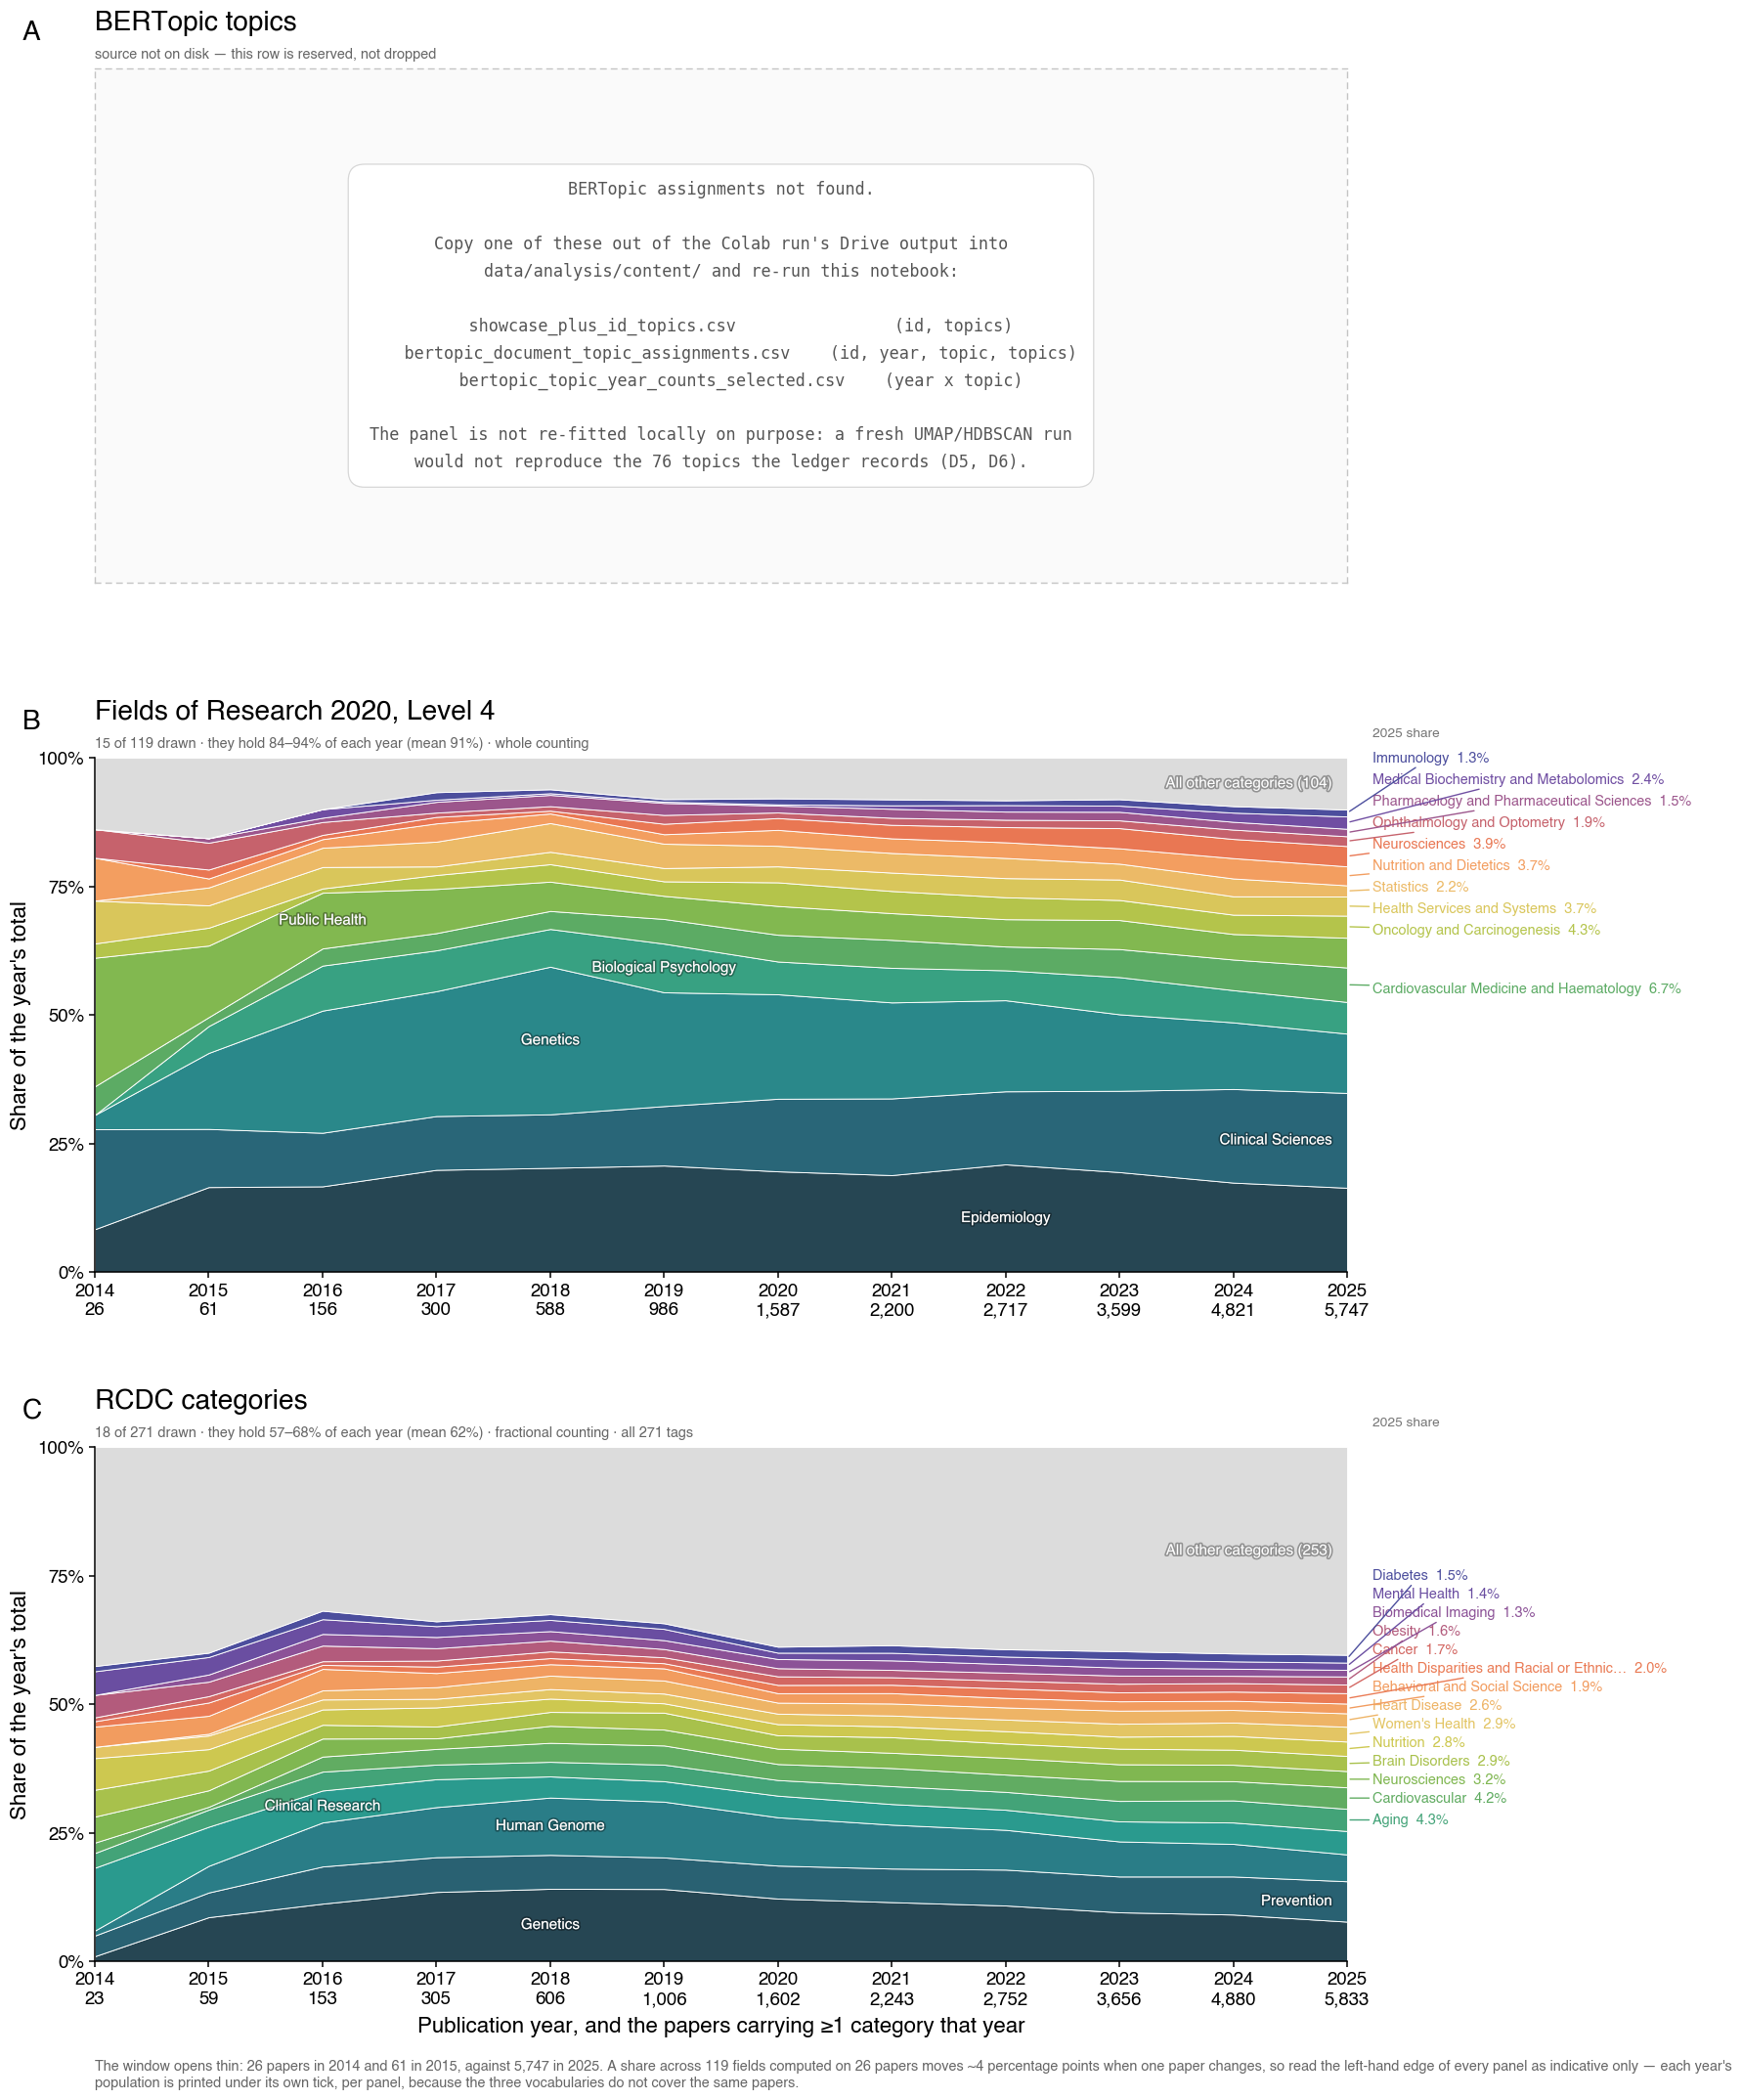

In [5]:
fig_main = CP.figure_main(D)

## 5. SI 1 — rank flow

The two bump charts `02_content_2` drew as `06b` and `07b`, re-drawn on the same bands the
main panel uses.

They are not on the main page because rank and share answer different questions and the
main page is already three panels of share. Nothing is discarded — the bands are the same
bands, out of the same `D`, so a line that is heavy here is a thick band there.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/02_content/02_02_supplementary_figure_01_category_rank_flow.pdf


saved output/figures/data_analysis/02_content/02_02_supplementary_figure_01_category_rank_flow.png


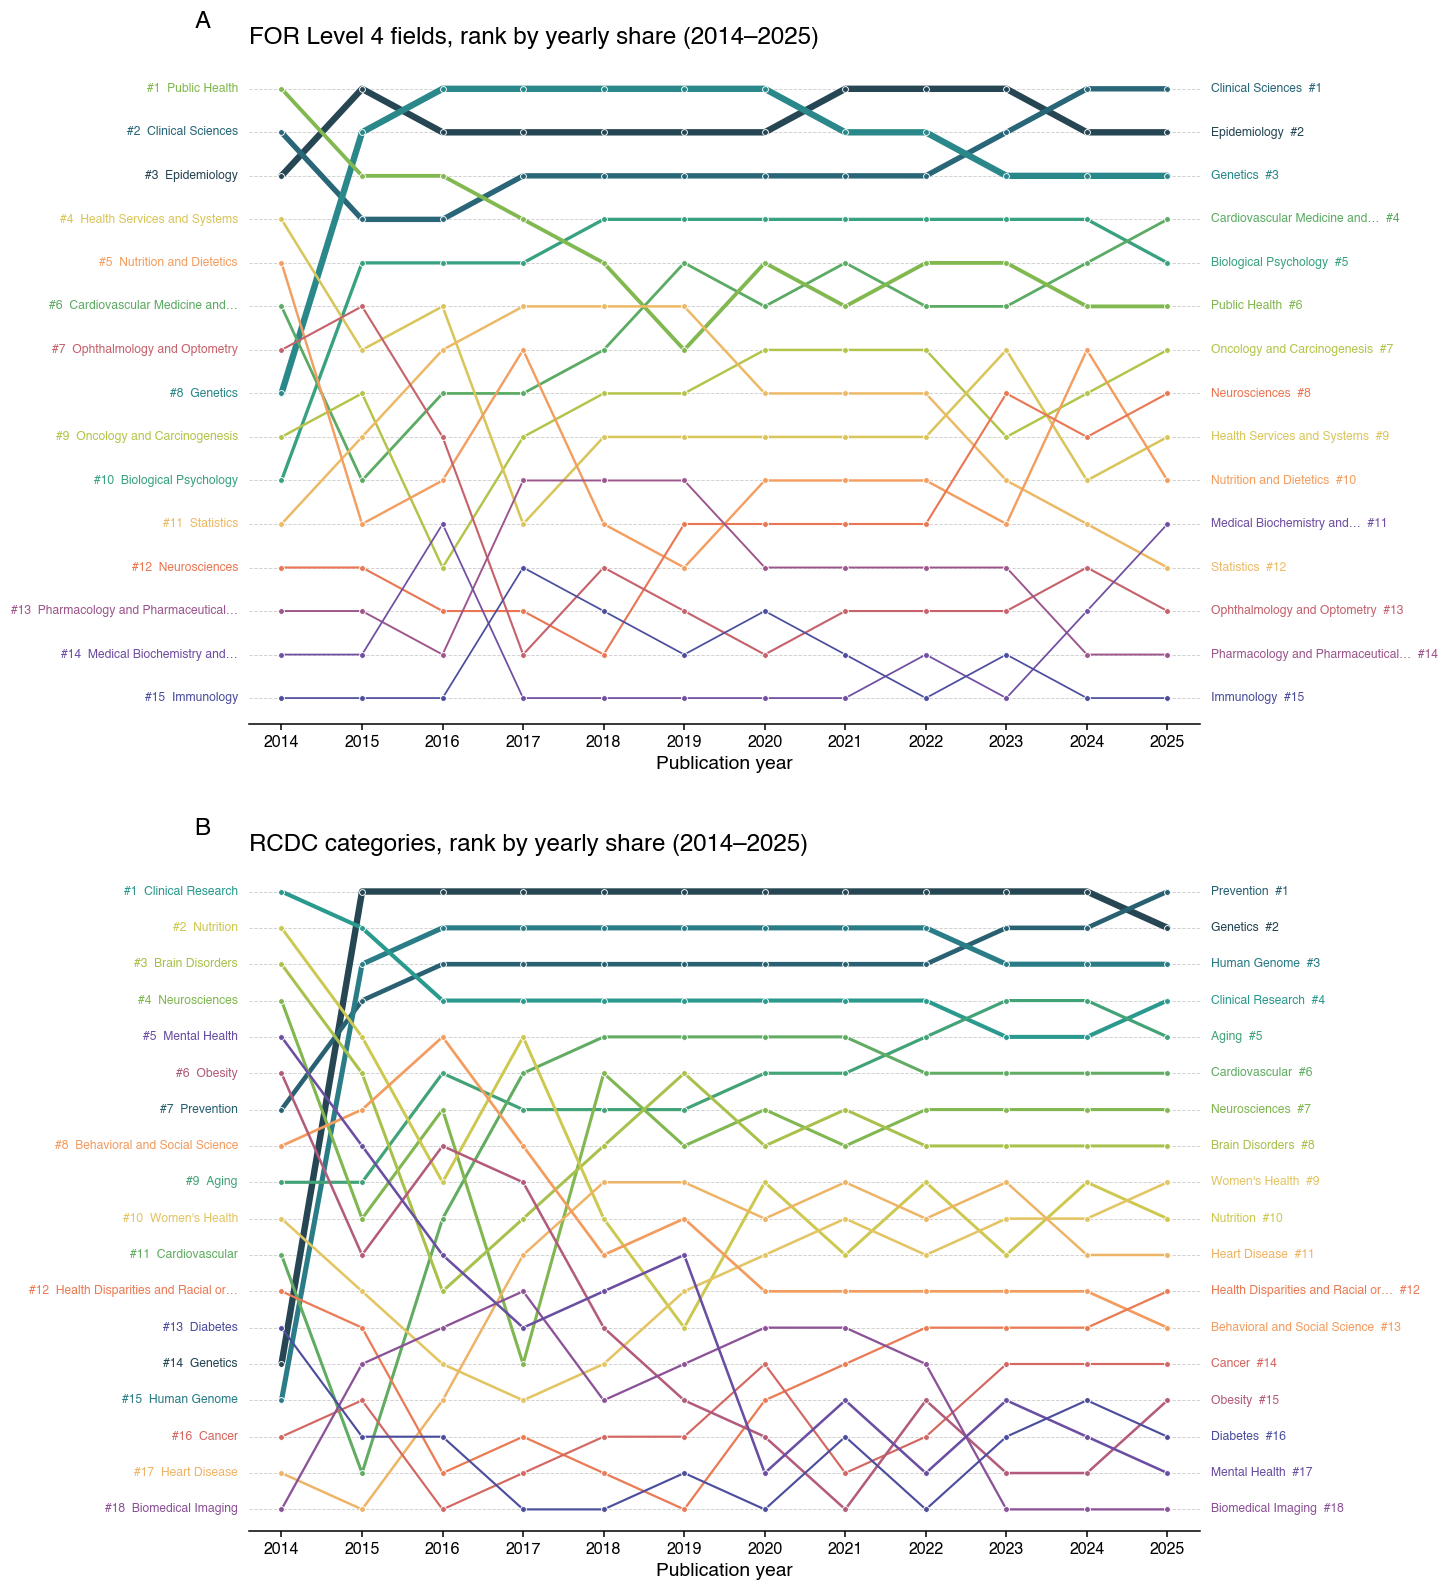

In [6]:
fig_si1 = CP.figure_si_rank_flow(D)

## 6. The tables behind the panels

The share matrices and the start-vs-end movement for each vocabulary. These are the
numbers a sentence in the paper should quote, rather than a value read off a band.

In [7]:
written_tables = []
for key, stem in (("topics", "topics"), ("for", "for_l4"), ("rcdc", "rcdc")):
    block = D[key]
    if not block["available"]:
        print(f"{key}: source absent, no table written")
        continue
    for frame, name in (
        (block["share"].round(4).reset_index(), f"panel_{stem}_year_share.csv"),
        (block["band"].round(4).reset_index(), f"panel_{stem}_drawn_bands.csv"),
        (CP.start_end_table(block["share"], block["keep"]).reset_index(),
         f"panel_{stem}_start_vs_end.csv"),
    ):
        frame.to_csv(TABLE_DIR / name, index=False)
        written_tables.append(name)
    print(f"{key}: {block['n_bands']} bands, "
          f"{block['coverage_mean']:.1f}% mean cover -> 3 tables")

display(CP.start_end_table(D["for"]["share"], D["for"]["keep"]))

topics: source absent, no table written
for: 15 bands, 90.6% mean cover -> 3 tables
rcdc: 18 bands, 62.3% mean cover -> 3 tables


,share_2014_%,share_2025_%,rank_2014,rank_2025,delta_pp,rank_change
category,,,,,,
Genetics,2.78,11.54,11,3,8.76,8
Epidemiology,8.33,16.39,3,2,8.06,1
Biological Psychology,0.00,6.15,33,5,6.15,28
Neurosciences,0.00,3.95,92,8,3.95,84
Medical Biochemistry and Metabolomics,0.00,2.40,85,11,2.40,74
Statistics,0.00,2.17,112,12,2.17,100
Oncology and Carcinogenesis,2.78,4.31,13,7,1.53,6
Pharmacology and Pharmaceutical Sciences,0.00,1.45,96,14,1.45,82
Immunology,0.00,1.34,74,16,1.34,58


## 7. What was written

Every file this notebook produced, with its size, so a re-run can be compared against the
last one rather than trusted.

The glob is `02_[0-9][0-9]_*` rather than `*`: `02_content_2_other_category_flow.ipynb`
writes its own eight figures (`05a`…`07b`) into the same directory and is still
responsible for them.

In [8]:
written = sorted(
    p for p in FIG_DIR.glob("02_[0-9][0-9]_*.*")
    if p.suffix.lower() in {".pdf", ".png", ".svg"}
)
manifest = pd.DataFrame([
    {"file": P.raw_path(p), "kb": p.stat().st_size // 1024,
     "modified": pd.Timestamp(p.stat().st_mtime, unit="s").round("s")}
    for p in written
])
manifest.to_csv(TABLE_DIR / "panel_manifest.csv", index=False)
print(f"{len(written)} figure files under {P.raw_path(FIG_DIR)} "
      f"({manifest.kb.sum() / 1024:.1f} MB) + {len(written_tables) + 3} tables\n")
display(manifest)

4 figure files under output/figures/data_analysis/02_content (7.5 MB) + 9 tables



,file,kb,modified
0,output/figures/data_analysis/02_content/02_01_...,98,2026-09-09 21:04:16
1,output/figures/data_analysis/02_content/02_01_...,3743,2026-09-09 21:04:19
2,output/figures/data_analysis/02_content/02_02_...,33,2026-09-09 21:04:20
3,output/figures/data_analysis/02_content/02_02_...,3835,2026-09-09 21:04:22
